In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"

# Verify it exists
import os
print("Contents:", os.listdir(BASE_PATH))

Contents: ['train', 'test-town-01', 'test-fog', 'validation', 'test', 'test-night', 'count_labels.py', 'visualize_dataset.py', 'train_classifiers.py', 'evaluate_classifiers.py']


 Install dependencies

In [3]:
!pip install scikit-learn -q

Class Distribution Analysis

In [4]:
import pandas as pd

TRAIN_CSV = f"{BASE_PATH}/train/train/labels.csv"
TEST_CSV  = f"{BASE_PATH}/test/test/labels.csv"

df_train = pd.read_csv(TRAIN_CSV, dtype={'frame': str})
df_test  = pd.read_csv(TEST_CSV, dtype={'frame': str})

labels = ["has_traffic_light", "has_pedestrian", "has_vehicle"]

print(f"Train size: {len(df_train)},  Test size: {len(df_test)}\n")

print("--- Training Split ---")
for col in labels:
    pct_true = df_train[col].sum() / len(df_train) * 100
    pct_false = 100 - pct_true
    print(f"  {col:<25}: {pct_true:5.1f}% True  |  {pct_false:5.1f}% False")

print("\n--- Test Split ---")
for col in labels:
    pct_true = df_test[col].sum() / len(df_test) * 100
    pct_false = 100 - pct_true
    print(f"  {col:<25}: {pct_true:5.1f}% True  |  {pct_false:5.1f}% False")


Train size: 7200,  Test size: 3600

--- Training Split ---
  has_traffic_light        :  73.3% True  |   26.7% False
  has_pedestrian           :  23.9% True  |   76.1% False
  has_vehicle              :  75.8% True  |   24.2% False

--- Test Split ---
  has_traffic_light        :  71.8% True  |   28.2% False
  has_pedestrian           :  19.6% True  |   80.4% False
  has_vehicle              :  75.0% True  |   25.0% False


Visualize Example Images

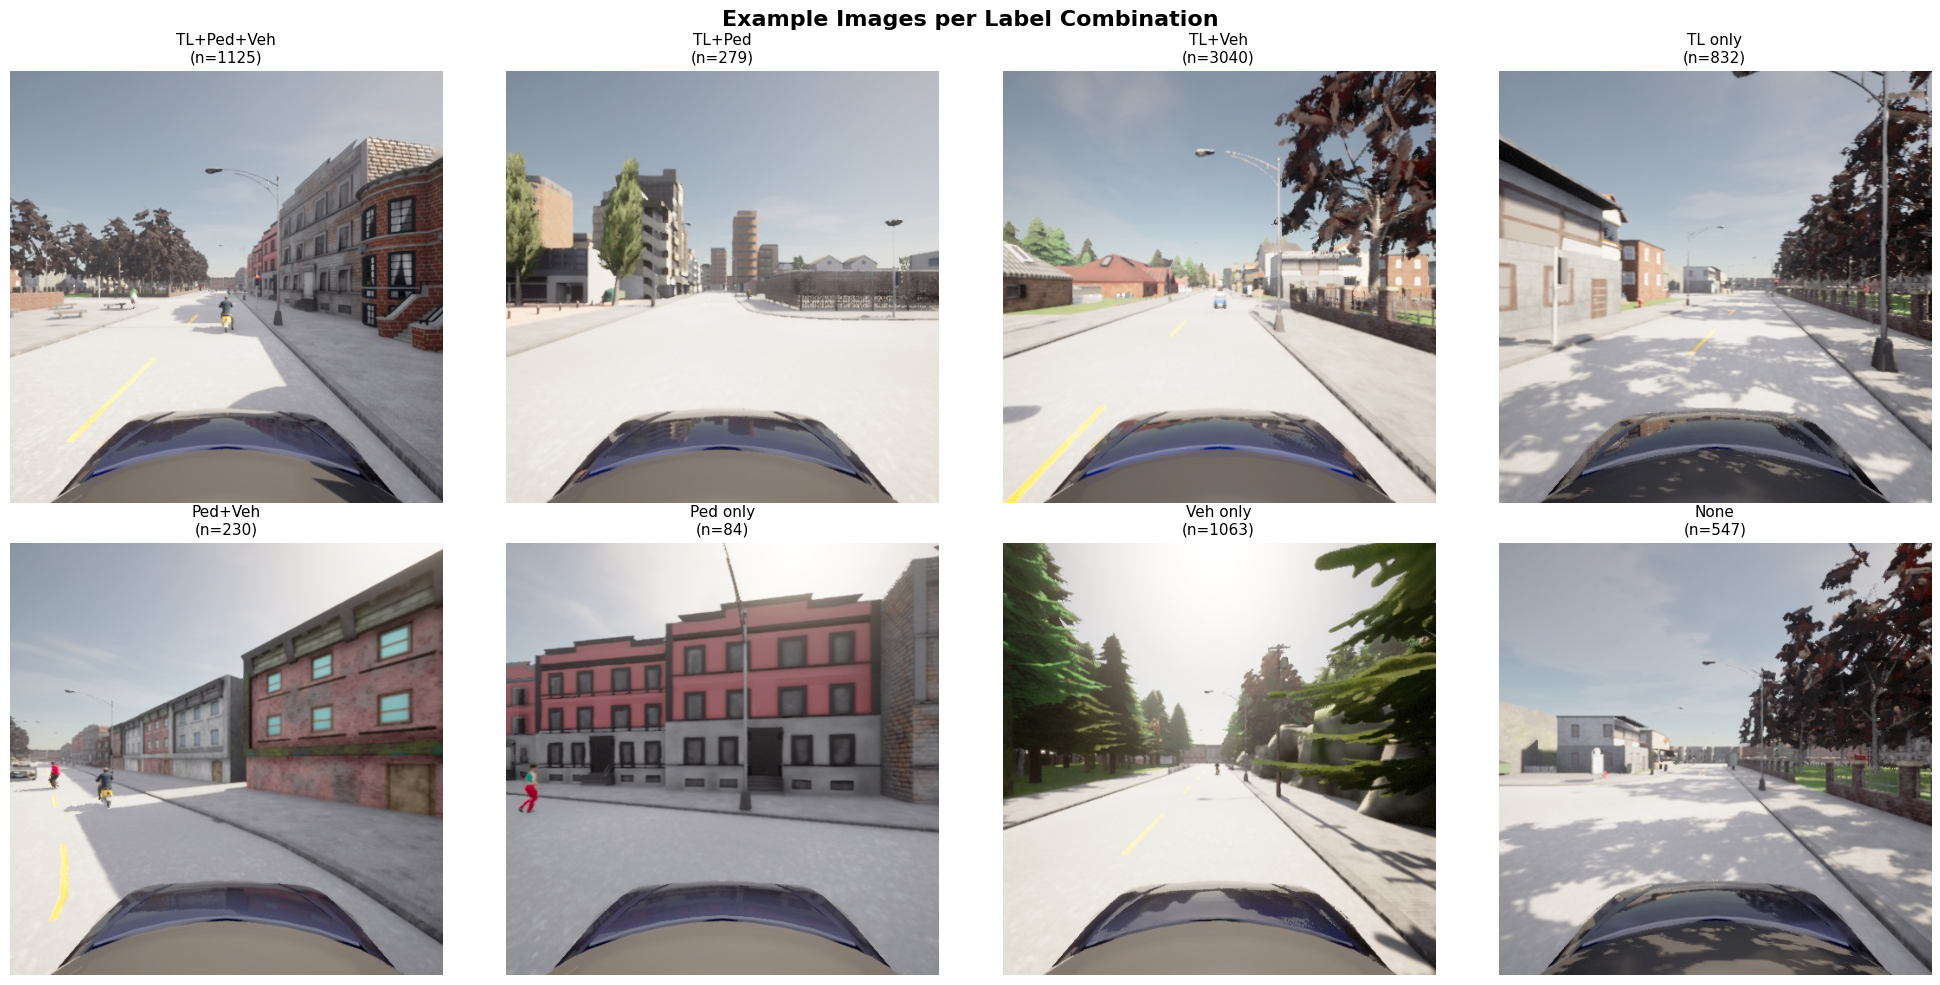

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_IMG = f"{BASE_PATH}/train/train/rgb-front"

# Show 3 random samples per label combination
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

combos = [
    (True, True, True, "TL+Ped+Veh"),
    (True, True, False, "TL+Ped"),
    (True, False, True, "TL+Veh"),
    (True, False, False, "TL only"),
    (False, True, True, "Ped+Veh"),
    (False, True, False, "Ped only"),
    (False, False, True, "Veh only"),
    (False, False, False, "None"),
]

for idx, (tl, ped, veh, title) in enumerate(combos):
    row, col = idx // 4, idx % 4
    mask = (
        (df_train['has_traffic_light'] == tl) &
        (df_train['has_pedestrian'] == ped) &
        (df_train['has_vehicle'] == veh)
    )
    subset = df_train[mask]
    if len(subset) > 0:
        frame = subset.iloc[0]['frame']
        img = Image.open(os.path.join(TRAIN_IMG, f"{frame}.jpg"))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{title}\n(n={len(subset)})", fontsize=11)
    else:
        axes[row, col].set_title(f"{title}\n(n=0)", fontsize=11)
    axes[row, col].axis('off')

plt.suptitle("Example Images per Label Combination", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Define Dataset, Model, Training Functions

In [6]:
import csv
import time
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Dataset ---
class DrivingDataset(Dataset):
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# --- Model ---
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(512, 1)
    return model.to(DEVICE)

# --- Class weight ---
def compute_pos_weight(dataset):
    labels = [s[1] for s in dataset.samples]
    num_pos = sum(labels)
    num_neg = len(labels) - num_pos
    if num_pos == 0:
        return torch.tensor([1.0])
    return torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)

# --- Train one epoch ---
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct += ((torch.sigmoid(out) > 0.5).float() == lbls).sum().item()
        total += lbls.size(0)
    return loss_sum / total, correct / total

# --- Validate ---
def validate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).unsqueeze(1)
            out = model(imgs)
            loss = criterion(out, lbls)
            loss_sum += loss.item() * imgs.size(0)
            correct += ((torch.sigmoid(out) > 0.5).float() == lbls).sum().item()
            total += lbls.size(0)
    return loss_sum / total, correct / total

print("✅ All functions defined.")



Using device: cuda
✅ All functions defined.


Train All 3 Classifiers

In [7]:
TRAIN_CSV = f"{BASE_PATH}/train/train/labels.csv"
TRAIN_IMG = f"{BASE_PATH}/train/train/rgb-front"
VAL_CSV   = f"{BASE_PATH}/validation/validation/labels.csv"
VAL_IMG   = f"{BASE_PATH}/validation/validation/rgb-front"
OUTPUT_DIR = f"{BASE_PATH}/model_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABELS = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']
NUM_EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-4

all_histories = {}

for label_col in LABELS:
    print(f"\n{'='*60}")
    print(f"  Training: {label_col}")
    print(f"{'='*60}")

    train_ds = DrivingDataset(TRAIN_CSV, TRAIN_IMG, label_col, train_transform)
    val_ds   = DrivingDataset(VAL_CSV, VAL_IMG, label_col, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = build_model()
    pos_weight = compute_pos_weight(train_ds)
    print(f"  pos_weight: {pos_weight.item():.2f}")

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_wts = None

    for epoch in range(NUM_EPOCHS):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = validate(model, val_loader, criterion)
        scheduler.step(vl)

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
              f"Train: {tl:.4f} ({ta:.4f}) | Val: {vl:.4f} ({va:.4f}) | {time.time()-t0:.1f}s")

        if vl < best_val_loss:
            best_val_loss = vl
            best_wts = copy.deepcopy(model.state_dict())

    # Save model
    path = os.path.join(OUTPUT_DIR, f"best_{label_col}.pth")
    torch.save(best_wts, path)
    print(f"  ✅ Saved → {path}")

    all_histories[label_col] = history

print("\n✅ All 3 models trained and saved!")




  Training: has_traffic_light
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


  pos_weight: 0.36
  Epoch  1/10 | Train: 0.0972 (0.9197) | Val: 0.0536 (0.9600) | 2233.4s
  Epoch  2/10 | Train: 0.0473 (0.9657) | Val: 0.0496 (0.9678) | 81.5s
  Epoch  3/10 | Train: 0.0300 (0.9792) | Val: 0.0594 (0.9564) | 82.1s
  Epoch  4/10 | Train: 0.0252 (0.9836) | Val: 0.0407 (0.9714) | 78.9s
  Epoch  5/10 | Train: 0.0220 (0.9842) | Val: 0.0407 (0.9803) | 82.0s
  Epoch  6/10 | Train: 0.0207 (0.9858) | Val: 0.0386 (0.9789) | 82.2s
  Epoch  7/10 | Train: 0.0135 (0.9897) | Val: 0.0501 (0.9725) | 81.3s
  Epoch  8/10 | Train: 0.0158 (0.9904) | Val: 0.0489 (0.9692) | 82.7s
  Epoch  9/10 | Train: 0.0125 (0.9908) | Val: 0.0504 (0.9767) | 84.7s
  Epoch 10/10 | Train: 0.0082 (0.9939) | Val: 0.0492 (0.9811) | 83.3s
  ✅ Saved → /content/drive/MyDrive/2026 (1)/2026/model_outputs/best_has_traffic_light.pth

  Training: has_pedestrian
  pos_weight: 3.19
  Epoch  1/10 | Train: 0.8972 (0.6664) | Val: 1.2184 (0.6761) | 83.7s
  Epoch  2/10 | Train: 0.6663 (0.7965) | Val: 1.3232 (0.6353) | 83.0s
  

Plot Loss & Accuracy Curves

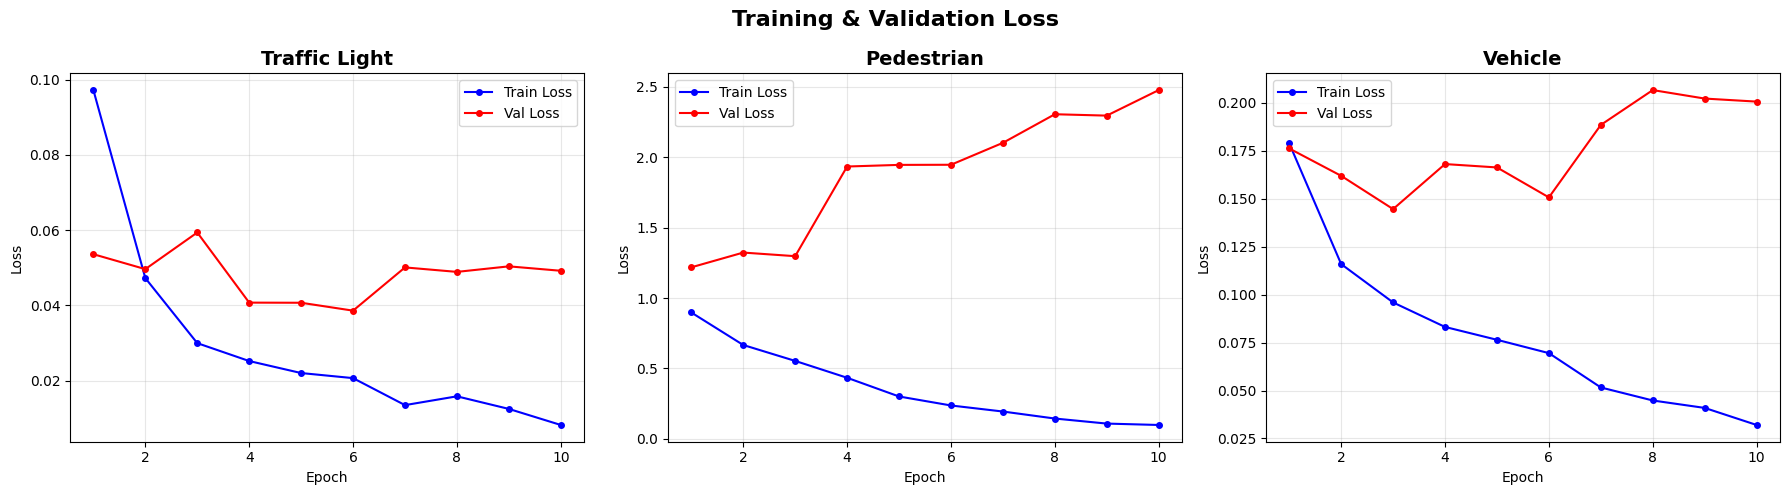

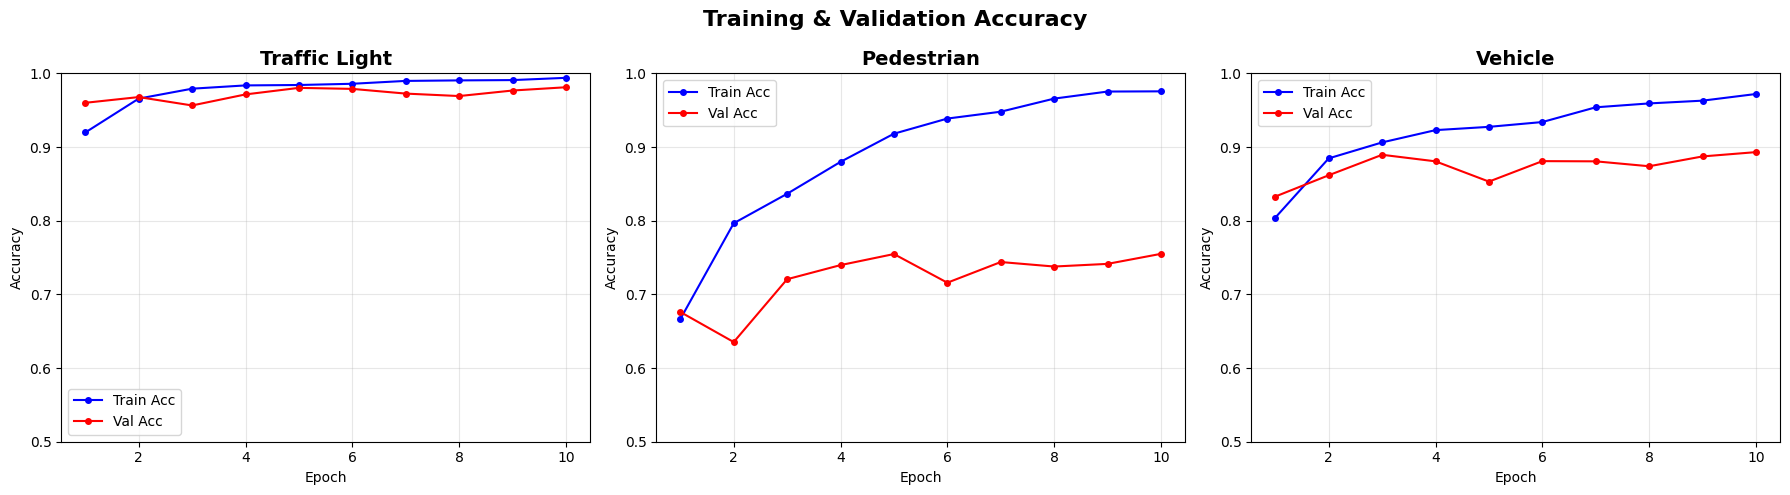

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (label, h) in enumerate(all_histories.items()):
    ax = axes[i]
    ep = range(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], 'b-o', label='Train Loss', ms=4)
    ax.plot(ep, h['val_loss'],   'r-o', label='Val Loss',   ms=4)
    ax.set_title(label.replace('has_','').replace('_',' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Training & Validation Loss', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (label, h) in enumerate(all_histories.items()):
    ax = axes[i]
    ep = range(1, len(h['train_acc']) + 1)
    ax.plot(ep, h['train_acc'], 'b-o', label='Train Acc', ms=4)
    ax.plot(ep, h['val_acc'],   'r-o', label='Val Acc',   ms=4)
    ax.set_title(label.replace('has_','').replace('_',' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([0.5, 1.0])
plt.suptitle('Training & Validation Accuracy', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()



Evaluate on Test Split

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

TEST_CSV = f"{BASE_PATH}/test/test/labels.csv"
TEST_IMG = f"{BASE_PATH}/test/test/rgb-front"

def load_model(label_col):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 1)
    path = os.path.join(OUTPUT_DIR, f"best_{label_col}.pth")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def get_predictions(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            preds = (torch.sigmoid(out).squeeze() > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

results = []
for label_col in LABELS:
    print(f"\n{'='*60}")
    print(f"  Evaluating: {label_col}")
    print(f"{'='*60}")

    model = load_model(label_col)
    test_ds = DrivingDataset(TEST_CSV, TEST_IMG, label_col, val_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    y_true, y_pred = get_predictions(model, test_loader)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n  Confusion Matrix:\n               Pred=0   Pred=1")
    print(f"    Actual=0   {cm[0][0]:>6}   {cm[0][1]:>6}")
    print(f"    Actual=1   {cm[1][0]:>6}   {cm[1][1]:>6}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['False','True'])}")

    results.append({'label': label_col, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})

# Summary table
print("\n" + "="*80)
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)
for r in results:
    print(f"{r['label']:<25} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['f1']:<12.4f}")
print("="*80)

worst = min(results, key=lambda x: x['f1'])
print(f"\nWorst model (by F1): {worst['label']}  (F1 = {worst['f1']:.4f})")




  Evaluating: has_traffic_light
  Accuracy:  0.9469
  Precision: 0.9450
  Recall:    0.9834
  F1-score:  0.9638

  Confusion Matrix:
               Pred=0   Pred=1
    Actual=0      868      148
    Actual=1       43     2541

              precision    recall  f1-score   support

       False       0.95      0.85      0.90      1016
        True       0.94      0.98      0.96      2584

    accuracy                           0.95      3600
   macro avg       0.95      0.92      0.93      3600
weighted avg       0.95      0.95      0.95      3600


  Evaluating: has_pedestrian
  Accuracy:  0.6553
  Precision: 0.2963
  Recall:    0.5510
  F1-score:  0.3853

  Confusion Matrix:
               Pred=0   Pred=1
    Actual=0     1970      924
    Actual=1      317      389

              precision    recall  f1-score   support

       False       0.86      0.68      0.76      2894
        True       0.30      0.55      0.39       706

    accuracy                           0.66      3600
  

In [11]:
!git config --global user.name "Vrundan"
!git config --global user.email "kvrundan@gmail.com"

%cd {BASE_PATH}


/content/drive/MyDrive/2026 (1)/2026


In [12]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/2026 (1)/2026/.git/


In [13]:
with open('.gitignore', 'w') as f:
    f.write("""# Dataset (too large)
train/
test/
test-fog/
test-night/
test-town-01/
validation/
# Model weights (too large)
model_outputs/*.pth
model_outputs/*.png
# Python cache
__pycache__/
*.pyc
# Misc
.DS_Store
Thumbs.db
calc_dist.html
.hydra/
""")
print("✅ .gitignore created")



✅ .gitignore created


In [14]:
!git add .gitignore train_classifiers.py evaluate_classifiers.py count_labels.py visualize_dataset.py


In [15]:
!git status


On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore
	new file:   count_labels.py
	new file:   evaluate_classifiers.py
	new file:   train_classifiers.py
	new file:   visualize_dataset.py



In [16]:
!git commit -m "Exercise Sheet 3: Binary classifiers for pedestrian, traffic light, vehicle detection"


[master (root-commit) e89696b] Exercise Sheet 3: Binary classifiers for pedestrian, traffic light, vehicle detection
 5 files changed, 601 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 count_labels.py
 create mode 100644 evaluate_classifiers.py
 create mode 100644 train_classifiers.py
 create mode 100644 visualize_dataset.py


In [26]:
%cd "/content/drive/MyDrive/Colab Notebooks"

/content/drive/MyDrive/Colab Notebooks


In [27]:
!ls


exercise3.ipynb  Untitled0.ipynb


In [29]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab Notebooks/.git/


In [30]:
!git config --global user.name "Vrundan"
!git config --global user.email "kvrundan@gmail.com"

In [31]:
!ls

exercise3.ipynb  Untitled0.ipynb
